# **ResNet-50 Feature Extraction + SVM**
*Created and runned with Google Colab*

This code has to be executed BEFORE all the other notebook, follow the numeration. \
**Dataset**: *Rare Neurological Diseases MRI - curated ver*, from [Kaggle](https://www.kaggle.com/datasets/ahsanneural/rare-neurological-diseases-mri-curated-edition) \
  

> This dataset is derived from the *"Benchmark Diagnostic MRI and Medical Imaging Dataset"* published on Mendeley Data by *Haseeb Hassan, M. Usman Akram, Waqas Ahmad, and Sajid Gul Khawaja (2024)*, available at this link [Mendeley Data](https://data.mendeley.com/datasets/d73rs38yk6/1)



**Goal**: Establish baseline with classical feature extraction, using *ResNet50* as a base, and then use *Support Vector Machine* for the final classification


## **1) Drive mount & Kaggle dataset's download**


In order to correctly configure the project, in your drive there must be the folder for the project, in my case is inside the folder I use for my University projects.
Plus, to download the dataset directly from Kaggle (to have the last version), it is required to copy an info from your Kaggle's account as follows:
- Go to [Kaggle' site](https://www.kaggle.com/) and log in it
- By intercat with your profile photo on the top-right, go to `Settings`
- Search for the section `API` and `Generate New Token`, it will open a pop up with some info:
  - **API TOKEN** (`KGAT_...`): This is your unique password. Copy it now, because Kaggle will never show it to you again

  - **Option 1** (`export KAGGLE_API_TOKEN=...`): It is used to save the token as a temporary environment variable in the terminal Linux/Mac.

  - **Option 2** (`mkdir -p ~/.kaggle && echo ...`): It is a terminal command that automatically creates the `~/.kaggle folder`, saves the token inside it in a file named `access_token`, and assigns the correct security permissions

  - **Final command** (kaggle competitions list): Example command to check if the token works.
- Copy the **API TOKEN** and return to Colab
- Open the menu on the left and intercat with the **key icon**
- Then add a **new secret**
  - **Name:** *KAGGLE_API_TOKEN*
  - **Value:** paste here the **API TOKEN**
- Finally, active the switch *"Notebook access"*



> If you don't want to use the key, you can **modify the code** when the key is required by pasting the API token in the else branch (section 2 of the following code)



By following those steps, you will be able to download the dataset directly from the Kaggle's site.


This cell is the only one that talks to the outside world. It does four things:
1. **Mounts Google Drive** so that data/features/models survive a runtime reset
2. **Reads the Kaggle token** from Colab Secrets (never hard-code it in a repo)
3. **Creates** the project folder tree on Drive
4. **Clones** the source repo and downloads the dataset if not already present

Everything downstream assumes the paths defined here.

In [ ]:
import os
from pathlib import Path
from google.colab import drive, userdata
import sys

# 1. Google Drive mount
# drive.mount() attaches the user's Drive under /content/drive
drive.mount('/content/drive')


# 2. Kaggle API configuration - AFTER adding the secret
# userdata.get() reads a secret stored in the Colab key panel
try:
    os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")
except Exception:
    # If you don't use Colab's Secret, you can directly paste your token here
    os.environ["KAGGLE_API_TOKEN"] = "KGAT_..."


# 3. Path configuration
# pathlib.Path is used instead of raw strings so that the "/" operator builds paths safely and the same code stays OS-independent
BASE_DIR = Path('/content/drive/MyDrive/University/rare-neuro-mri')
DATA_DIR = BASE_DIR / "data"                       # where to save dataset
MODEL_DIR = BASE_DIR / "resnet models"             # where to save the model
UTILS_DIR = BASE_DIR / "resnet utils"              # where to save useful files created during the analysis

# Create the base folder and the 'data' subfolder if they do not already exist
# parents=True  -> also create missing intermediate folders
# exist_ok=True -> do not raise if the folder is already there (idempotent cell)
for d in [DATA_DIR, MODEL_DIR, UTILS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# 4. Clone GitHub repo & add src folder to the project
REPO_URL = "https://github.com/Rayoyo/rare-neuro-mri.git"
REPO_DIR = Path("/content/rare-neuro-mri")

if not REPO_DIR.exists():
    !git clone {REPO_URL} {REPO_DIR}
print("Repo cloned!")

# repo added to importable moduls
if str(REPO_DIR) not in sys.path:
    sys.path.append(str(REPO_DIR))


# 5. Kaggle's dataset
# The "slug" is the <owner>/<dataset-name> identifier shown in the Kaggle URL
DATASET_SLUG = "ahsanneural/rare-neurological-diseases-mri-curated-edition"    #can be seen on Kaggle too when you want to download the file


# 6. Download verification and execution
# If the data folder is not empty, skip the download
if any(DATA_DIR.iterdir()):
    print(f" Dataset already present in: {DATA_DIR}")
    print("Folder contents:")
    for item in DATA_DIR.iterdir():
        print(f" - {item.name}")
else:
    print(f" Empty folder. Downloading the dataset '{DATASET_SLUG}'...")

    # Ensure that the Kaggle library is installed
    !pip install -q kaggle

    # Download and extract the data directly into the data folder on Drive
    !kaggle datasets download -d {DATASET_SLUG} -p "{DATA_DIR}" --unzip

    print(f"\n Download and extraction completed successfully!")
    print(f"The files are located in: {DATA_DIR}")


Mounted at /content/drive
Cloning into '/content/rare-neuro-mri'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 64 (delta 28), reused 40 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 5.56 MiB | 14.66 MiB/s, done.
Resolving deltas: 100% (28/28), done.
Repo cloned!
 Dataset already present in: /content/drive/MyDrive/University/rare-neuro-mri/data
Folder contents:
 - rare_neuro_mri_curated


## **2) Install dependencies**

In this section are downloaded the requirements from the file in the github's repo.

- **Preferred path:** install the exact pinned versions from the repo's requirements.txt, so the notebook is reproducible across runtimes

- **Fallback path:** install only the minimum needed if the repo is unavailable \
`torchio` is installed separately because it provides the medical-imaging augmentations (random affine, bias field, noise) used by `dataset.py`



> Note: `-q` keeps `pip` quiet. \
After installing packages that are already imported by Colab (e.g. numpy/torch), a runtime restart may be required




In [2]:
# ---------------------------------------------------------
# Install & import dependencies
# ---------------------------------------------------------

requirements_file = REPO_DIR / "requirements.txt"
if requirements_file.exists():
    !pip install -q -r {requirements_file}
    !pip install -q torchio
else:
   # Minimal fallback stack: ML utilities + plotting + progress bars
    !pip install -q scikit-learn matplotlib seaborn tqdm
    !pip install -q torchio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.6/203.6 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 19.2 MB/s eta 0:00:00


In [3]:
# Core imports: deep-learning backend, data handling, plotting, image I/O
import torch
import sys
import pandas as pd
import os
import matplotlib.pyplot as plt
import random
from PIL import Image
from torch.utils.data import DataLoader

In [4]:
# Classical ML stack (scikit-learn): everything after the CNN feature extractor
from pathlib import Path
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [5]:
# ---------------------------------------------------------
# Reproducibility & Device Setup
# ---------------------------------------------------------

In [6]:
'''The repo root was already appended to sys.path, but the modules live in
<repo>/src and are written as top-level modules (not a package), so src/ must
be on the path as well. insert(0, ...) puts it FIRST, so a local dataset.py
wins over any same-named installed package'''
src_dir_path = REPO_DIR / "src"
if str(src_dir_path) not in sys.path:
    sys.path.insert(0, str(src_dir_path))

'''What each imported helper does:
   set_dataset_root        -> stores the dataset path globally for the module
   build_dataloaders       -> builds train/val/test Datasets (augmentation on train only)
   visualize_augmentations -> side-by-side original vs. transformed preview
   set_seed                -> seeds random / numpy / torch for reproducibility
   get_resnet50_extractor  -> ImageNet-pretrained ResNet-50 with the classifier head removed
   extract_features        -> runs the backbone in inference mode, returns (X, y)
   save_features           -> persists the feature matrices as .npy on Drive
   evaluate_and_save_all   -> metrics + plots + few-shot study + artifact saving'''
from dataset import set_dataset_root, build_dataloaders, visualize_augmentations, set_seed
from feature_extraction import get_resnet50_extractor, extract_features, save_features
from metrics import evaluate_and_save_all

In [7]:
# Select GPU if available, CPU if not
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


## **3) Dataset structure & exploration**

This section is divided into three main codes:
1. **Data Structure Overview** \
Walk the dataset tree and print it as an indented outline, to verify that the folder layout matches what the `ImageFolder-style loader` expects: `<root>/<split>/<class_name>/<image>.jpg`

2. **Class Distribution** \
Counting images per (split, class) is the cheapest sanity check on a dataset: it reveals class imbalance, empty folders, or a broken download before any training time is wasted. \
Here it also confirms the counts declared on Kaggle
3. **Sample Grid Visualization** \
Qualitative inspection before modelling: one row per disease, n random training slices per row \
The goal is to see acquisition planes, contrast and preprocessing style, and to spot corrupted or off-domain images early

In [8]:
# ---------------------------------------------------------
# Data Structure Overview
# ---------------------------------------------------------

DATASET_ROOT = DATA_DIR / "rare_neuro_mri_curated"

# os.walk() yields (current_dir, subdirs, files) recursively, top-down
for root, dirs, files in os.walk(DATASET_ROOT):
  # Depth is inferred by counting the path separators left after stripping
  # the root prefix -> used to indent the printed tree
    level = root.replace(str(DATASET_ROOT), '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    if level < 3 and files:
        for f in files[:3]:
            print(f'{subindent}{f} ...')
        if len(files) > 3:
            print(f'{subindent}... and {len(files)-3} more files')

rare_neuro_mri_curated/
  disease_summary.csv ...
  metadata.csv ...
  test/
    fukuyama_muscular_dystrophy/
      fukuyama_muscular_dystrophy_test_0000.jpg ...
      fukuyama_muscular_dystrophy_test_0001.jpg ...
      fukuyama_muscular_dystrophy_test_0002.jpg ...
      ... and 57 more files
    hallervorden_spatz_disease/
      hallervorden_spatz_disease_test_0000.jpg ...
      hallervorden_spatz_disease_test_0001.jpg ...
      hallervorden_spatz_disease_test_0002.jpg ...
      ... and 57 more files
    moyamoya_disease/
      moyamoya_disease_test_0000.jpg ...
      moyamoya_disease_test_0001.jpg ...
      moyamoya_disease_test_0002.jpg ...
      ... and 57 more files
    pachygyria_cerebellar_hypoplasia/
      pachygyria_cerebellar_hypoplasia_test_0000.jpg ...
      pachygyria_cerebellar_hypoplasia_test_0001.jpg ...
      pachygyria_cerebellar_hypoplasia_test_0002.jpg ...
      ... and 57 more files
    walker_warburg_syndrome/
      walker_warburg_syndrome_test_0000.jpg ...
      

In [9]:
# ---------------------------------------------------------
# Class Distribution  - confirm kaggle's info
# ---------------------------------------------------------

splits = ['train', 'val', 'test']
disease_classes = []
split_stats = {}                 # nested dict: {split: {class: n_images}}

for split in splits:
    split_path = DATASET_ROOT / split
    if not split_path.exists():  # skip a split that was not shipped
        continue

    # sorted() guarantees a deterministic class order, which must match the
    # label indices assigned later by the dataset loader
    classes = sorted([d for d in os.listdir(split_path) if (split_path / d).is_dir()])
    disease_classes = classes
    split_stats[split] = {}

    for cls in classes:
        cls_path = split_path / cls
        n_images = len([
            # Count only real image files
            f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        split_stats[split][cls] = n_images

# The dict-of-dicts maps naturally to a DataFrame: rows = classes, cols = splits
df_stats = pd.DataFrame(split_stats).fillna(0).astype(int)
print("\nDataset Statistics:")
print(df_stats)
print(f"Total images: {df_stats.sum().sum()}")
print(f"Classes: {disease_classes}")


Dataset Statistics:
                                  train  val  test
fukuyama_muscular_dystrophy         280   60    60
hallervorden_spatz_disease          280   60    60
moyamoya_disease                    280   60    60
pachygyria_cerebellar_hypoplasia    280   60    60
walker_warburg_syndrome             280   60    60
Total images: 2000
Classes: ['fukuyama_muscular_dystrophy', 'hallervorden_spatz_disease', 'moyamoya_disease', 'pachygyria_cerebellar_hypoplasia', 'walker_warburg_syndrome']



> ***Output comment:*** \
The dataset is perfectly balanced - 280 train / 60 val / 60 test for each of the 5 classes, 2000 images in total (70/15/15 split) \
Perfect balance is why plain accuracy is a fair metric in this case, and why macro-F1 and weighted-F1 come out almost identical later on


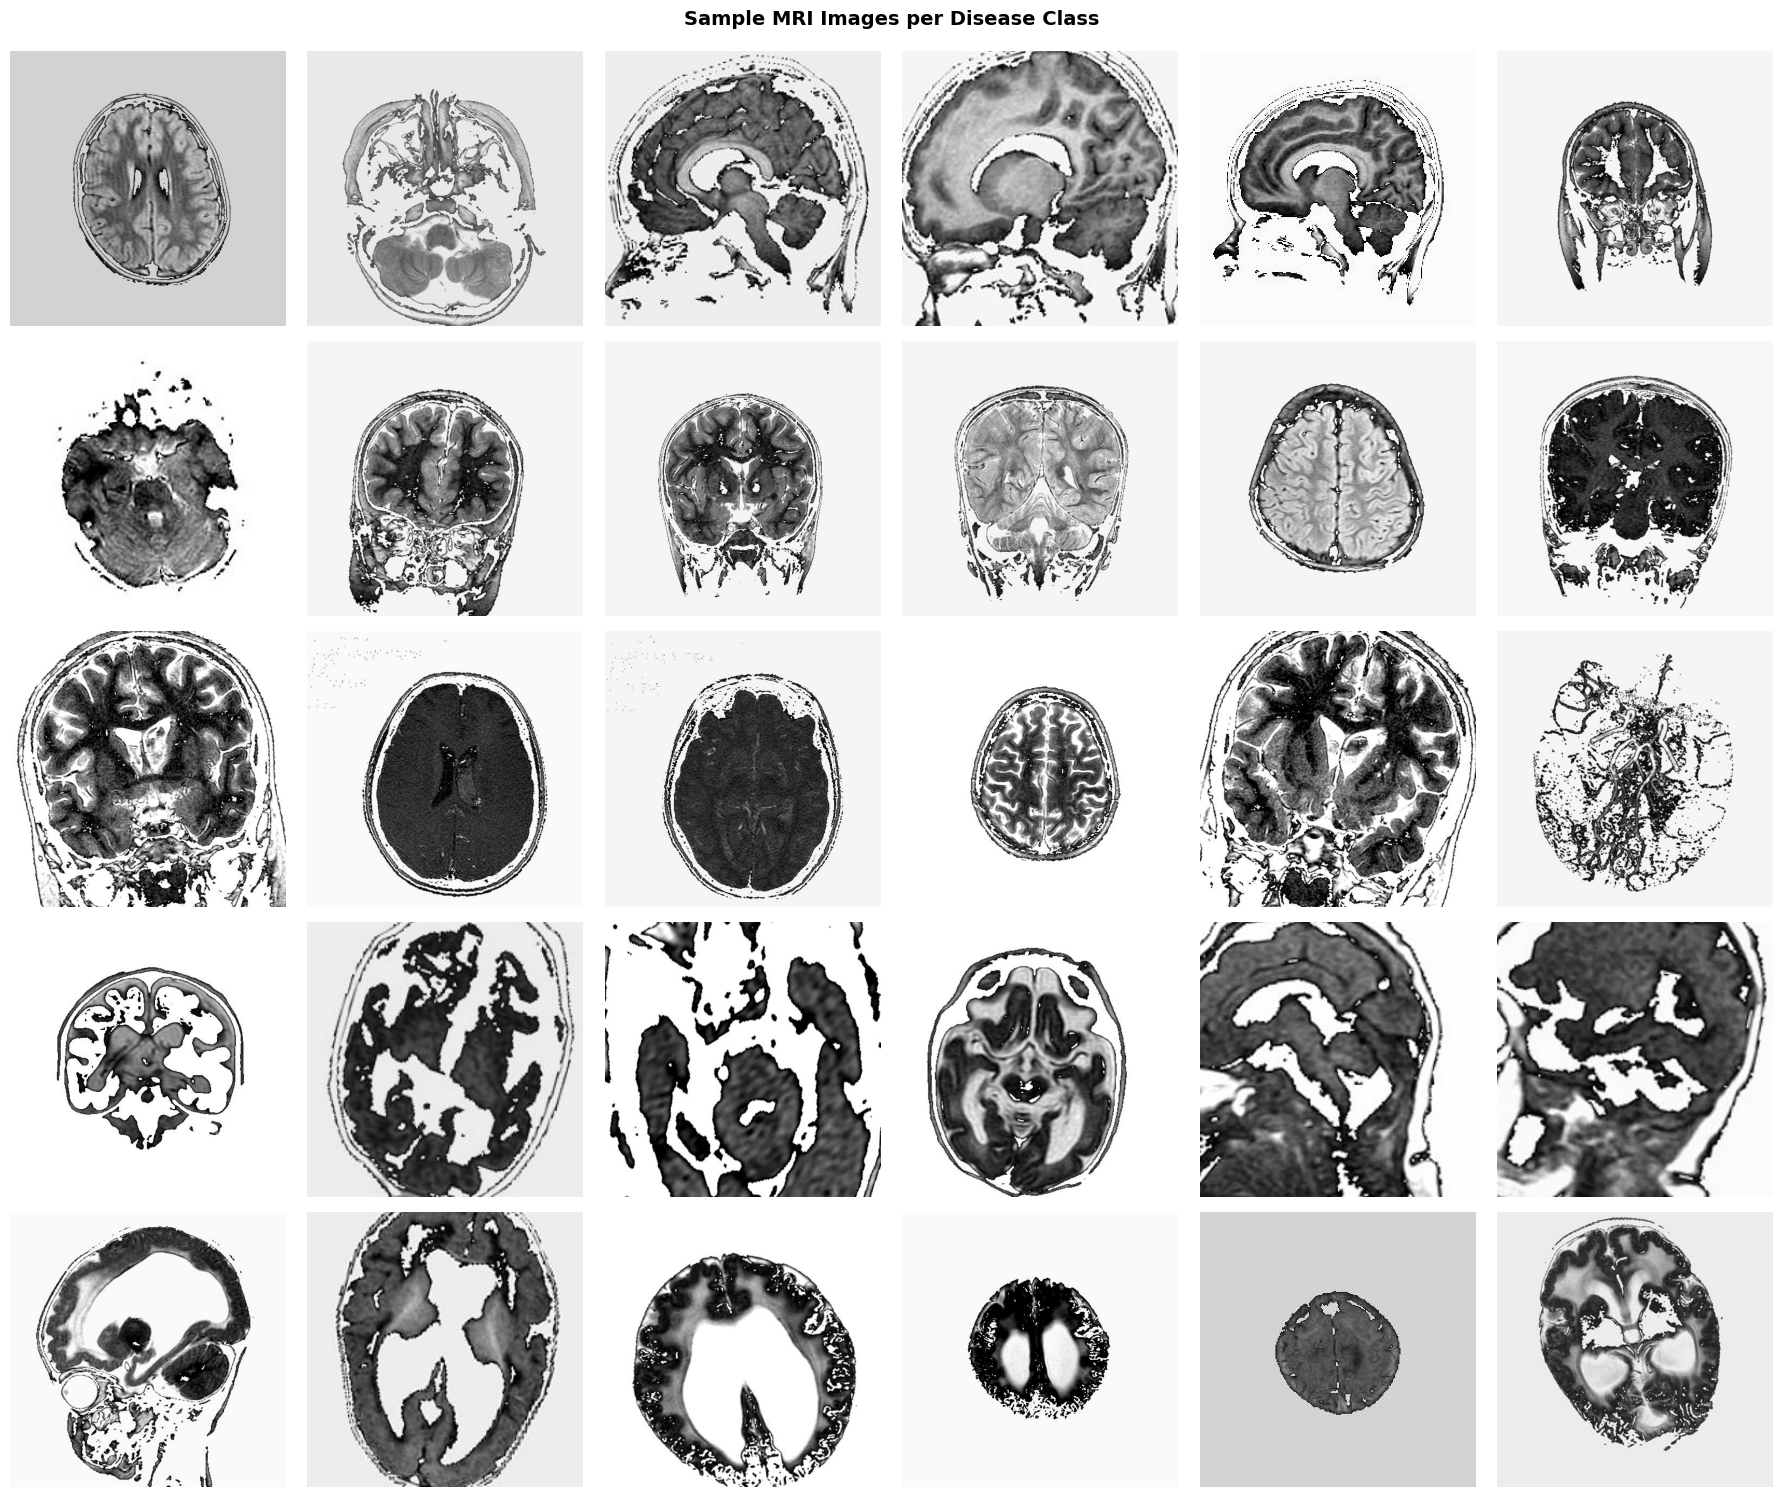

In [10]:
# ---------------------------------------------------------
# Sample Grid Visualization
# ---------------------------------------------------------

def show_samples(n_per_class=4):
  # One subplot row per class, one column per requested sample
    fig, axes = plt.subplots(len(disease_classes), n_per_class,
                             figsize=(n_per_class*3, len(disease_classes)*3))
    train_path = os.path.join(DATASET_ROOT, 'train')

    for i, cls in enumerate(disease_classes):
        cls_path = os.path.join(train_path, cls)
        images = [f for f in os.listdir(cls_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        # random.sample() draws WITHOUT replacement, so no duplicated tiles
        # min(...) protects against classes with fewer images than requested
        sampled = random.sample(images, min(n_per_class, len(images)))
        for j, img_name in enumerate(sampled):
            img_path = os.path.join(cls_path, img_name)
            img = Image.open(img_path)
            # cmap='gray' only when the file is single-channel ('L' mode)
            # RGB files must be shown without a colormap
            axes[i, j].imshow(img, cmap='gray' if img.mode == 'L' else None)
            axes[i, j].axis('off')
            if j == 0:
                '''CAVEAT: axis('off') above hides the whole axis, including its ylabel -
                so this class name is NOT rendered in the figure
                Use axes[i, j].set_title(cls) or ax.text(...) instead if the row labels are needed'''
                axes[i, j].set_ylabel(cls, fontsize=10, fontweight='bold',
                                      rotation=0, ha='right', va='center')

    plt.suptitle('Sample MRI Images per Disease Class', fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(UTILS_DIR / "sample_grid.png", dpi=150, bbox_inches='tight')
    plt.show()

show_samples(6)

> ### **Output comment:**  *Sample MRI Images per Disease Class*
>
> **What is plotted:** A 5x6 grid: one row per disease (rows follow the alphabetical order of `disease_classes`, i.e. *fukuyama muscular dystrophy*, *hallervorden spatz disease*, *moyamoya disease*, *pachygyria cerebellar hypoplasia*, *walker warburg syndrome*), six random training slices per row.
>
> **What it shows**
> - The dataset mixes **axial, coronal and sagittal planes inside the same class**: row 1 in particular contains several mid-sagittal slices (corpus callosum and brainstem visible), while row 2 is mostly coronal and row 3 mostly axial. Head size also varies from paediatric to adult, so the model must be robust to acquisition geometry, not only to pathology
> - The images are **not raw DICOM**: they have been window-levelled and heavily contrast-stretched, which produces the saturated black/white regions and the speckled skull outlines
> - **A few tiles are over-processed to the point of losing anatomy** — e.g. the last tile of row 3, where thresholding has reduced the slice to a sparse edge/vessel map on a white background. These are legitimate members of the dataset, but they are the images most likely to be misread
> - **Contrast style differs visibly between rows**: row 3 shows dark parenchyma with a bright skull rim, row 4 is high-contrast with thick white CSF spaces, row 5 shows the enlarged ventricles and posterior-fossa cysts typical of Walker–Warburg, clinically plausible
> - Some tiles are **zoomed or cropped** (row 4, last two) and all are square-resized, so a few images look stretched
>
> **Note on reproducibility:** this grid is drawn with `random.sample()` in a cell that runs *before* `set_seed(SEED)`, so **it changes at every run** and will not match the figure of a previous execution. Move the seeding above this cell if the figure has to be stable for the report.

## **4) Data transformation**

In this part are done some things:
- Set the global seed used in the notebook
- Initialization of the dataset in order to use the data augmentation only during the training
- Are shown some random samples of the transformation done
- The standard PyTorch data loaders is initialized

In [11]:
# Global seed on notebook & dataset root
'''set_seed() seeds Python's random, NumPy and PyTorch in one call, so the augmentations,
the train/val sampling and the SVM tie-breaking are repeatable
Any change to SEED changes every stochastic result in the notebook
'''
SEED = 33
set_seed(SEED)

set_dataset_root(DATASET_ROOT)

Global dataset root set to: /content/drive/MyDrive/University/rare-neuro-mri/data/rare_neuro_mri_curated


In [12]:
# Dataset initialization (Data Augmentation active only on train)
'''Arguments:
   batch_size = 32  -> used internally by the helper for its own loaders
   img_size   = 224 -> ResNet-50's native input resolution (ImageNet standard)
   aug_factor = 2   -> each training image is yielded twice per epoch with different random transforms,
                       doubling the effective training set (1400 -> 2800 samples)
   seed             -> makes the random transforms reproducible
 Val and test are deliberately left un-augmented: they must measure performance on untouched data

 these three objects are Datasets, not DataLoaders, despite the helper's name -
 the actual DataLoaders are built a few cells below
'''
train_ds, val_ds, test_ds = build_dataloaders(
    dataset_root=DATASET_ROOT,
    batch_size=32,
    img_size=224,
    aug_factor=2,  # Double the on-the-fly generated training samples per epoch
    seed=SEED
)

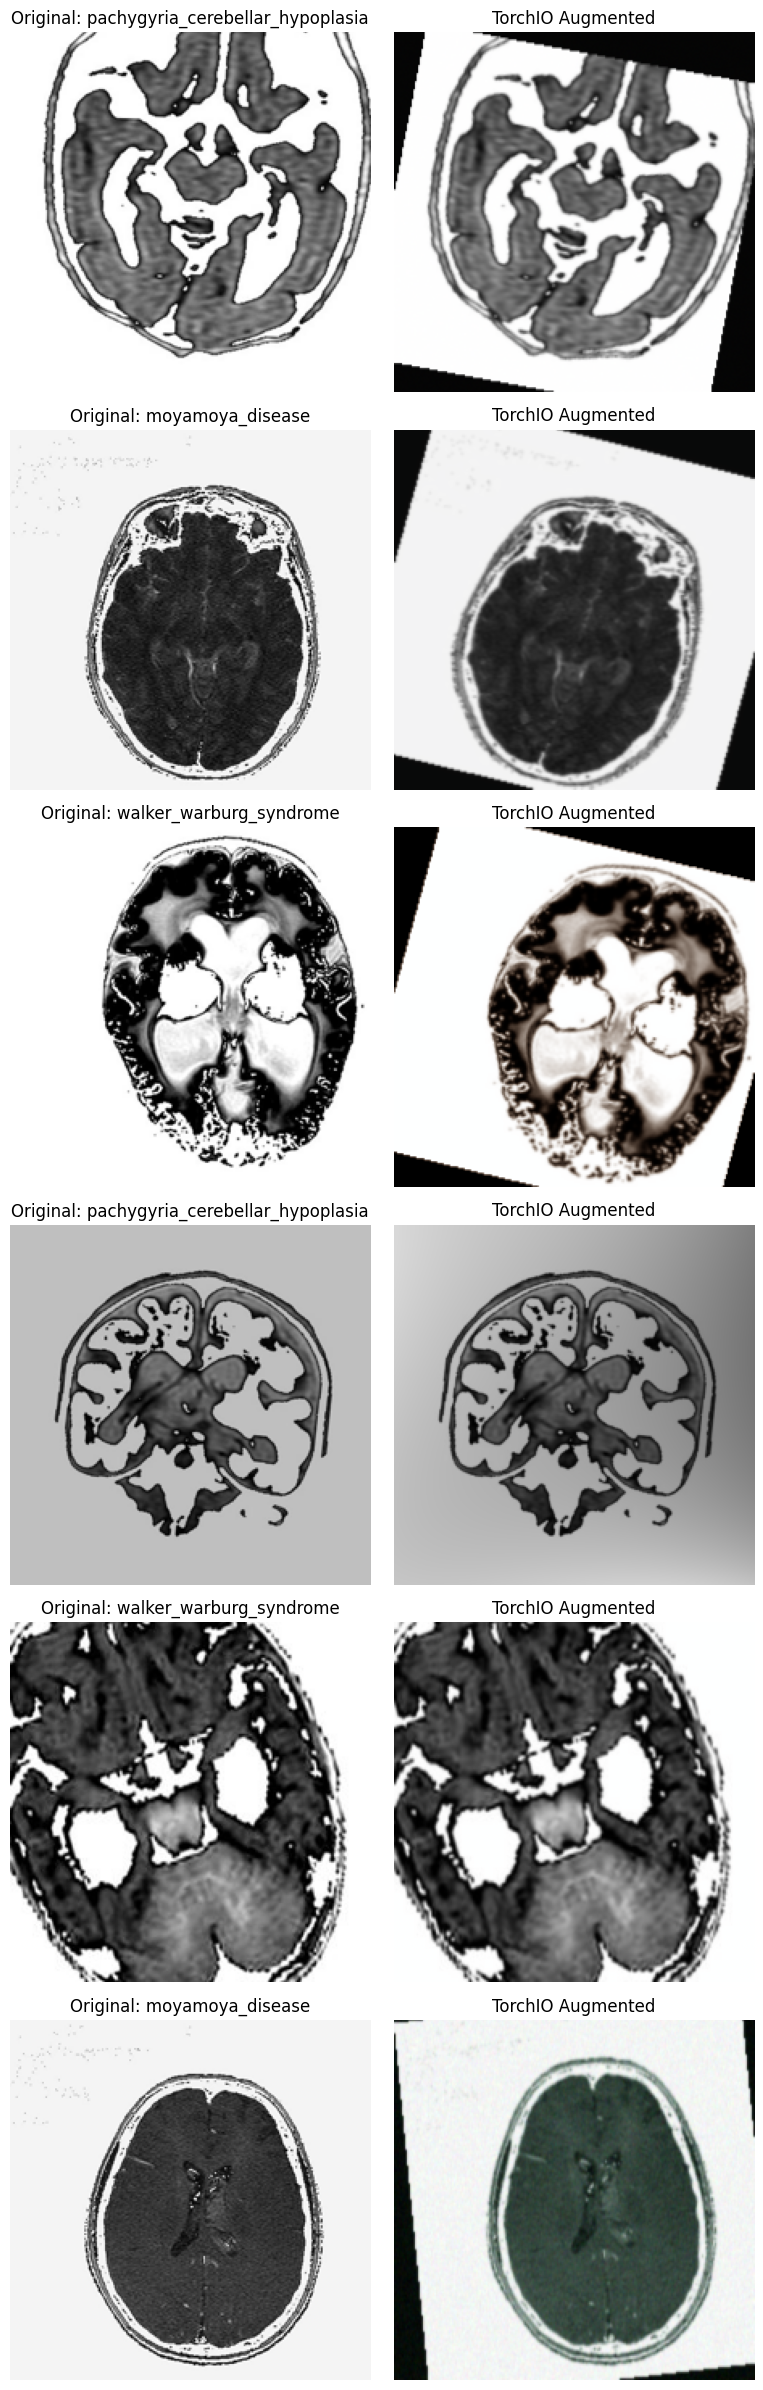

In [13]:
# View some random examples to verify the quality of the transformations
'''Prints original vs. transformed pairs
Overly aggressive transforms (extreme rotation, intensity shifts that erase the lesion,
flips that break left/right anatomy) silently destroy the signal the model is supposed to learn
Same seed as above -> same samples every run'''

visualize_augmentations(train_ds, num_samples=6, seed=SEED)

> ### **Output comment:** *Original vs. TorchIO-augmented samples*
>
> **What is plotted:** Six random training samples, each as an *original / augmented* pair, produced by the TorchIO pipeline that is active on the training split only
>
> **Transforms visible in this run**
> - **Random affine rotation** (rows 1–3): the tilted brain plus the black triangular corners left by zero-padding after rotation.
> - **Random bias field** (row 4): the smooth intensity gradient across the image, mimicking MRI coil inhomogeneity — a genuinely domain-appropriate augmentation.
> - **Noise / intensity jitter** (rows 3 and 5): grain and contrast changes.
> - **Colour shift** (row 6): the greenish cast indicates the transform acted on a 3-channel copy of the slice; harmless for the ResNet input, but worth checking if strict greyscale is expected.
>
> **Verdict.** Anatomy remains recognisable in every pair — rotations are moderate and no lesion is erased — so the augmentation is strong enough to add variety without destroying the diagnostic signal

In [14]:
# Initialize the standard PyTorch DataLoaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

## **5) ResNet-50**

The ImageNet-pretrained ResNet-50 is used as a frozen feature extractor - the final fully-connected classifier is removed, so each image is mapped to the 2048-D global-average-pooled embedding.

Those embeddings then feed a linear SVM. This is the standard "CNN features + classical classifier" baseline: cheap, stable on small datasets, and hard to beat when data is limited

- **Feature Extraction** /
***Workflow***: rebuild datasets -> load backbone -> extract -> save to Drive
- **PCA Visualization** \
A purely diagnostic, unsupervised look at the embedding space \
PCA finds the orthogonal directions of maximum variance and we keep the first two to get a 2-D scatter \
NOT part of the classification pipeline
- **SVM hyperparameter tuning** \
A linear SVM finds the hyperplane maximising the margin between classes
- **Final SVM training & test evaluation** \
Standard protocol once the hyperparameter is chosen: retrain on Train+Val (more data = better estimator) and evaluate ONCE on the held-out test set \
The test set is touched only here and must not influence any further choice


In [15]:
# ---------------------------------------------------------
# Load Model & Feature Extraction
# ---------------------------------------------------------

# Datasets are rebuilt here with batch_size=64 (faster extraction than the 32 used  previously)
train_ds, val_ds, test_ds = build_dataloaders(DATASET_ROOT, batch_size=64, aug_factor=2, seed=SEED)
disease_classes = list(train_ds.class_to_idx.keys())

# ResNet-50 extractor
extractor = get_resnet50_extractor(DEVICE)

# feature extraction
x_train, y_train = extract_features(extractor, train_ds, DEVICE, desc="Extracting Train Features")
x_val, y_val = extract_features(extractor, val_ds, DEVICE, desc="Extracting Val Features")
x_test, y_test = extract_features(extractor, test_ds, DEVICE, desc="Extracting Test Features")

# feature saving
features_dict = {
    "x_train.npy": x_train, "y_train.npy": y_train,
    "x_val.npy": x_val,     "y_val.npy": y_val,
    "x_test.npy": x_test,   "y_test.npy": y_test,
}
save_features(MODEL_DIR, features_dict)
print(f"\n All features have been successfully saved in: {MODEL_DIR}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 132MB/s]
Extracting Test Features: 100%|██████████| 5/5 [01:15<00:00, 15.01s/it]



✅ All features have been saved in: /content/drive/MyDrive/University/rare-neuro-mri/restnet models

 All features have been successfully saved in: /content/drive/MyDrive/University/rare-neuro-mri/restnet models


> **Output comment** \
The backbone weights are downloaded once (~98 MB) and cached, then the three splits are embedded: **44 batches for train (2800 augmented samples), 5 + 5 for val and test (300 each)** at `batch_size=64` \
Total extraction time in this run is about **7 minutes on GPU** (`Device: cuda`), against roughly 26 minutes for the same work on CPU: on a CPU runtime this single cell dominates the whole notebook \
The features are then written to Drive as `.npy`, so every following notebook can load them and skip the CNN pass entirely

### **PCA Visualization**

PCA projects the multidimensional space ($2048$ dimensions) onto $2$ dimensions to assess the separability of the $5$ neurological conditions

It maximises variance, so features with a larger numeric range would dominate the components

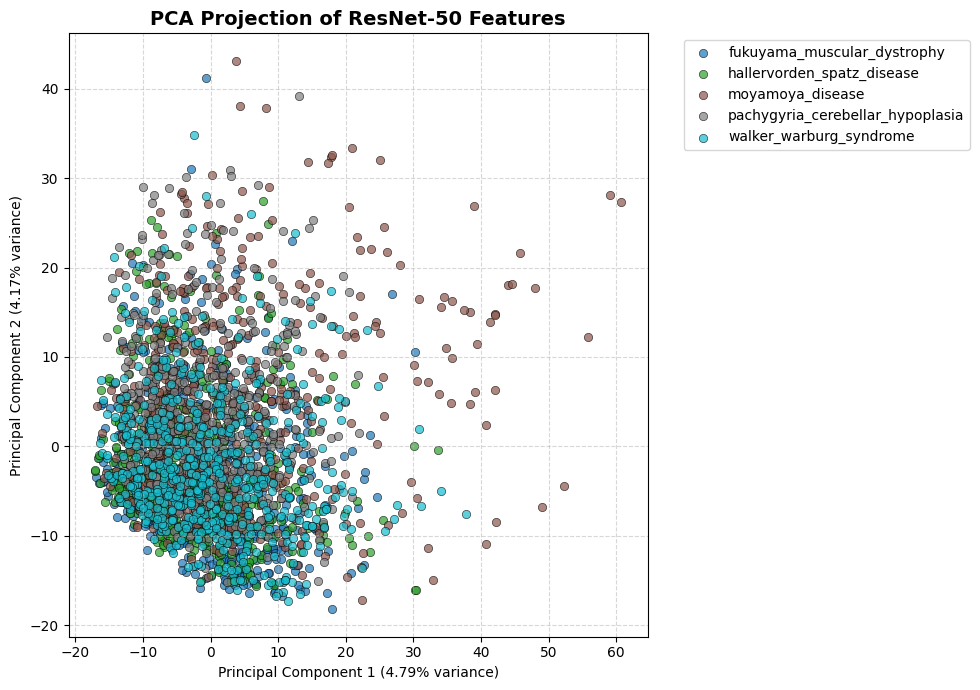

In [25]:
# ---------------------------------------------------------
# PCA Visualization
# ---------------------------------------------------------

def plot_pca_features(X, y, class_names, title="PCA Projection of ResNet-50 Features"):
    # Pre-normalization (fundamental for PCA)

    # StandardScaler puts every one of the 2048 dimensions at mean 0, std 1
    X_scaled = StandardScaler().fit_transform(X)

    # Reduction to 2 principal components
    pca = PCA(n_components=2, random_state=SEED)
    X_pca = pca.fit_transform(X_scaled)

    # Share of the total variance captured by each component, in percent
    var_exp = pca.explained_variance_ratio_ * 100

    plt.figure(figsize=(10, 7))
    # A qualitative colormap sampled at len(class_names) discrete colors
    colors = plt.colormaps["tab10"].resampled(len(class_names))

    # One scatter() call per class so that each gets its own legend entry
    for i, cls in enumerate(class_names):
        mask = (y == i)         # boolean mask selecting this class's rows
        plt.scatter(
            X_pca[mask, 0],      # PC1 coordinate
            X_pca[mask, 1],      # PC2 coordinate
            label=cls,
            alpha=0.7,           # transparency reveals point density
            edgecolors='k',
            linewidths=0.5,
            c=[colors(i)]        # wrapped in a list: one RGBA tuple, not a value list
        )

    # Axis labels carry the explained variance - always report it, otherwise the
    # plot cannot be interpreted honestly.
    plt.xlabel(f"Principal Component 1 ({var_exp[0]:.2f}% variance)")
    plt.ylabel(f"Principal Component 2 ({var_exp[1]:.2f}% variance)")
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')   # legend outside the axes
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Perform PCA visualization on the training set
plot_pca_features(x_train, y_train, disease_classes)

> ### **Output comment:** *PCA Projection of ResNet-50 Features*
>
> **What is plotted:** The 2800 augmented training embeddings, standardized and projected from **2048 dimensions onto the first 2 principal components**, coloured by class
>
> - **The two components explain only 4.79% + 4.17% = 8.96% of the total variance.** More than 91% of the information is in the discarded directions, so this scatter is a *very* lossy shadow of the real feature space
> - The five classes form **one large overlapping cloud** with no visually separable clusters. Only a slight structure is noticeable: *moyamoya* (brown) is the only class that spreads far to the right along PC1 (up to ~60), while *walker–warburg* (cyan) is densely packed on the left. PC1 therefore looks like an "image style / intensity" axis rather than a disease axis
>
> This apparent overlap does **not** contradict the 98.3% test accuracy obtained later. PCA is unsupervised — it maximises variance, not class separation — and here most variance encodes nuisance factors (acquisition plane, brightness, head size) rather than pathology \
The SVM works in the full 2048-D space, where a hyperplane can exploit directions that PC1 and PC2 simply do not show \
If a separability plot is needed for a report, a supervised projection (**LDA**) or a neighbourhood-preserving one (**t-SNE**, **UMAP**) would be far more informative than PCA

### **SVM Hyperparameter Tuning**

*C is the regularization trade-off:*
- small C = wide margin, more tolerated violations (stronger regularization)
- large C = the model tries harder to classify every training point correctly (risk of overfitting)

The search is a plain grid over a log scale, selected on the *VALIDATION* set

In [26]:
# ---------------------------------------------------------
# SVM Hyperparameter Tuning
# ---------------------------------------------------------

# Standardization (StandardScaler fit on Train, transform on Val)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(x_train)
X_val_s = scaler.transform(x_val)

C_values = [0.01, 0.1, 1, 10, 100]       # log-spaced grid, 4 orders of magnitude
best_C = None
best_val_f1 = 0

print("Hyperparameter tuning (Linear SVM)...")
for C in C_values:
  # kernel='linear' -> no kernel trick
  # appropriate because 2048-D CNN embeddings are already close to linearly separable,
  # and it is far faster than RBF on this many dimensions
  svm = SVC(kernel='linear', C=C, random_state=SEED)
  svm.fit(X_train_s, y_train)
  val_preds = svm.predict(X_val_s)

  # average='macro' -> unweighted mean of the per-class F1 scores,
  # so every disease counts equally regardless of support
  val_f1 = f1_score(y_val, val_preds, average='macro')
  val_acc = accuracy_score(y_val, val_preds)

  print(f"  C={C:>6.2f} | Val Acc: {val_acc:.4f} | Val Macro-F1: {val_f1:.4f}")

  # Strict > means that in case of a tie the FIRST (smallest) C wins,
  # which is the desirable behaviour: prefer the simpler, more regularized model
  if val_f1 > best_val_f1:
    best_val_f1 = val_f1
    best_C = C

print(f"\nBest C: {best_C} (Val Macro-F1: {best_val_f1:.4f})")

Hyperparameter tuning (Linear SVM)...
  C=  0.01 | Val Acc: 0.9833 | Val Macro-F1: 0.9833
  C=  0.10 | Val Acc: 0.9833 | Val Macro-F1: 0.9833
  C=  1.00 | Val Acc: 0.9833 | Val Macro-F1: 0.9833
  C= 10.00 | Val Acc: 0.9833 | Val Macro-F1: 0.9833
  C=100.00 | Val Acc: 0.9833 | Val Macro-F1: 0.9833

Best C: 0.01 (Val Macro-F1: 0.9833)


> **Output comment** \
All five values of C give exactly the same validation score (0.9833 accuracy / 0.9833 macro-F1 - i.e. 5 errors out of 300) \
The grid is completely flat over four orders of magnitude, meaning the classes are almost perfectly linearly separable in the embedding space and regularization is simply not the binding constraint
> Thanks to the strict `>` above, the smallest C (0.01) is selected: the widest margin among equally-performing models, hence the best expected generalization

### **Final SVM Training & Test Evaluation**

In [27]:
# ---------------------------------------------------------
# Final SVM Training & Test Evaluation
# ---------------------------------------------------------

# Combining training and validation sets for final retraining
# np.vstack stacks the feature matrices row-wise (3100 x 2048), np.concatenate
# does the same for the 1-D label vectors
X_tv = np.vstack([x_train, x_val])
y_tv = np.concatenate([y_train, y_val])

# A NEW scaler is fitted on the combined Train+Val set,
# because the training distribution has changed
# The test set is only transformed - never fitted
scaler_final = StandardScaler()
X_tv_s = scaler_final.fit_transform(X_tv)
X_test_s = scaler_final.transform(x_test)

'''Final SVM training with the best C found
probability=True enables predict_proba, but it makes fitting noticeably
slower: scikit-learn runs an internal 5-fold cross-validation to calibrate Platt scaling
Worth it only if calibrated scores are actually needed
(ROC curves, confidence thresholds, error analysis)'''
final_svm = SVC(kernel='linear', C=best_C, probability=True, random_state=SEED)
final_svm.fit(X_tv_s, y_tv)

# Prediction on Test Set
test_preds = final_svm.predict(X_test_s)
test_proba = final_svm.predict_proba(X_test_s)

test_acc = accuracy_score(y_test, test_preds)
test_macro_f1 = f1_score(y_test, test_preds, average='macro')

print("=" * 60)
print("RESNET-50 + SVM — FINAL TEST RESULTS")
print("=" * 60)
print(f"Test Accuracy:     {test_acc:.4f}")
print(f"Test Macro-F1:     {test_macro_f1:.4f}")
print("\nDetailed Report:")
# classification_report gives per-class precision / recall / F1 / support:
# the aggregate score alone can hide one badly-served class
print(classification_report(y_test, test_preds, target_names=disease_classes, digits=4))

RESNET-50 + SVM — FINAL TEST RESULTS
Test Accuracy:     0.9833
Test Macro-F1:     0.9834

Detailed Report:
                                  precision    recall  f1-score   support

     fukuyama_muscular_dystrophy     0.9231    1.0000    0.9600        60
      hallervorden_spatz_disease     1.0000    0.9333    0.9655        60
                moyamoya_disease     1.0000    1.0000    1.0000        60
pachygyria_cerebellar_hypoplasia     1.0000    1.0000    1.0000        60
         walker_warburg_syndrome     1.0000    0.9833    0.9916        60

                        accuracy                         0.9833       300
                       macro avg     0.9846    0.9833    0.9834       300
                    weighted avg     0.9846    0.9833    0.9834       300



> **Output comment** \
98.33% accuracy and 0.9834 macro-F1 -> **5 misclassified images out of 300** \
Three classes are perfect on every metric (`moyamoya_disease`, `pachygyria_cerebellar_hypoplasia`, and `fukuyama_muscular_dystrophy` on recall) \
The interesting asymmetry is between the two remaining columns: `fukuyama_muscular_dystrophy` has **recall 1.0000 but precision 0.9231** (it catches all its own cases *and* attracts 5 foreign ones), while `hallervorden_spatz_disease` has **precision 1.0000 but recall 0.9333** (never predicted wrongly, but it loses 4 of its 60 slices) \
So the model is not making scattered mistakes: it has a **one-directional bias towards the fukuyama class**, which the confusion matrix below makes explicit

## **6) Metrics evaluations**

Single call that:
1. recomputes and prints the full metric set,
2. renders the confusion matrix and the per-class bar chart,
3. runs the few-shot robustness experiment,
4. saves plots + model files

Everything needed to reproduce an inference later, bundled for pickling

Saving the scaler alongside the SVM is essential: a new image must be scaled with the SAME statistics seen at training time, or predictions are garbage

 EVALUATION RESULTS: RESNET50_SVM
Test Accuracy:     0.9833
Test Macro-F1:     0.9834
Test Weighted-F1:  0.9834

Detailed Classification Report:
                                  precision    recall  f1-score   support

     fukuyama_muscular_dystrophy     0.9231    1.0000    0.9600        60
      hallervorden_spatz_disease     1.0000    0.9333    0.9655        60
                moyamoya_disease     1.0000    1.0000    1.0000        60
pachygyria_cerebellar_hypoplasia     1.0000    1.0000    1.0000        60
         walker_warburg_syndrome     1.0000    0.9833    0.9916        60

                        accuracy                         0.9833       300
                       macro avg     0.9846    0.9833    0.9834       300
                    weighted avg     0.9846    0.9833    0.9834       300



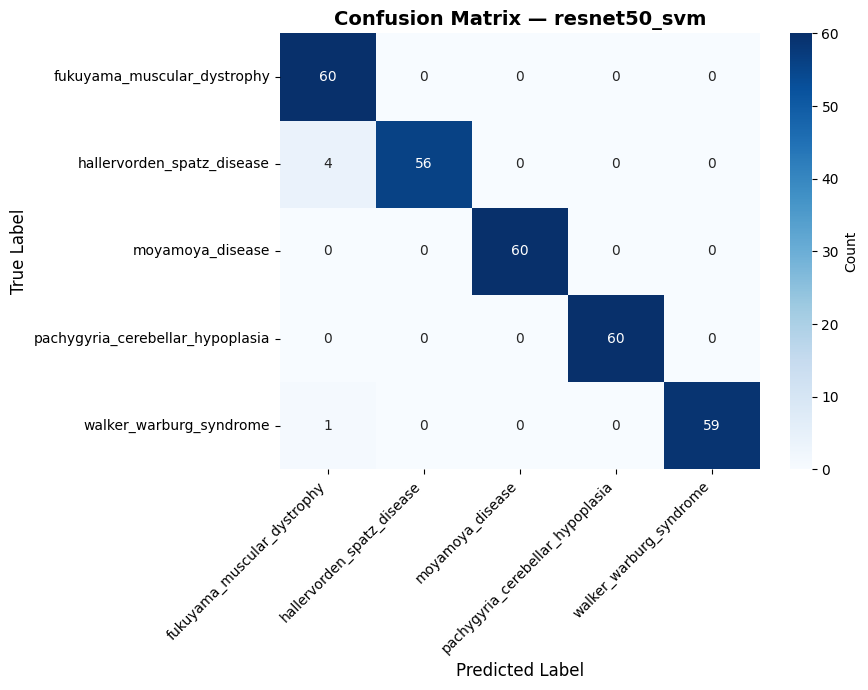

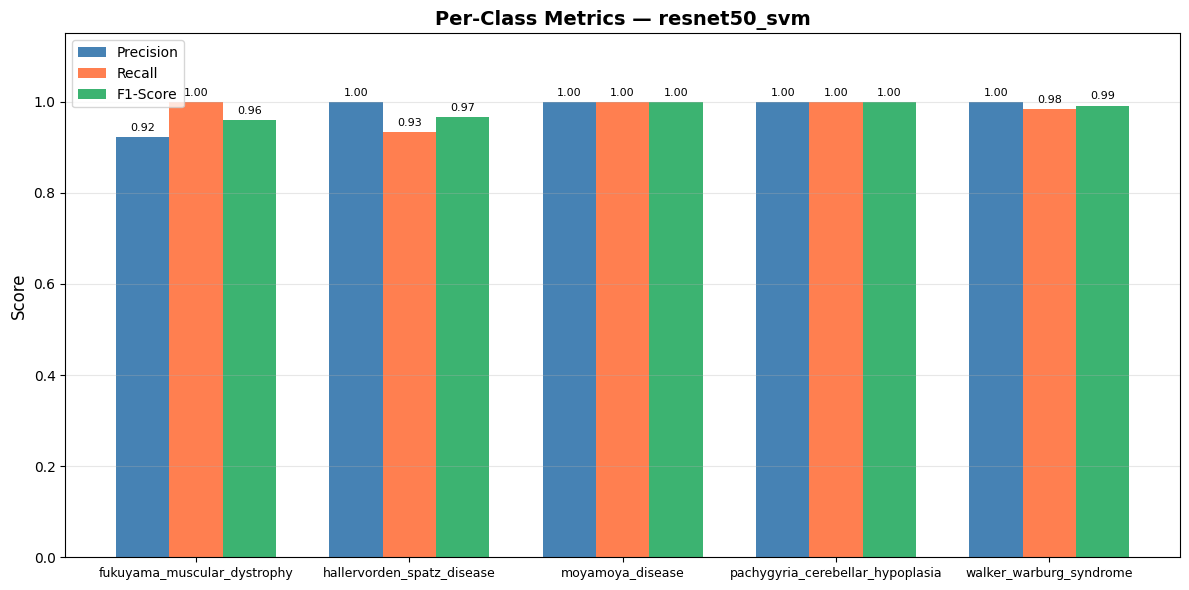


Running few-shot experiments...


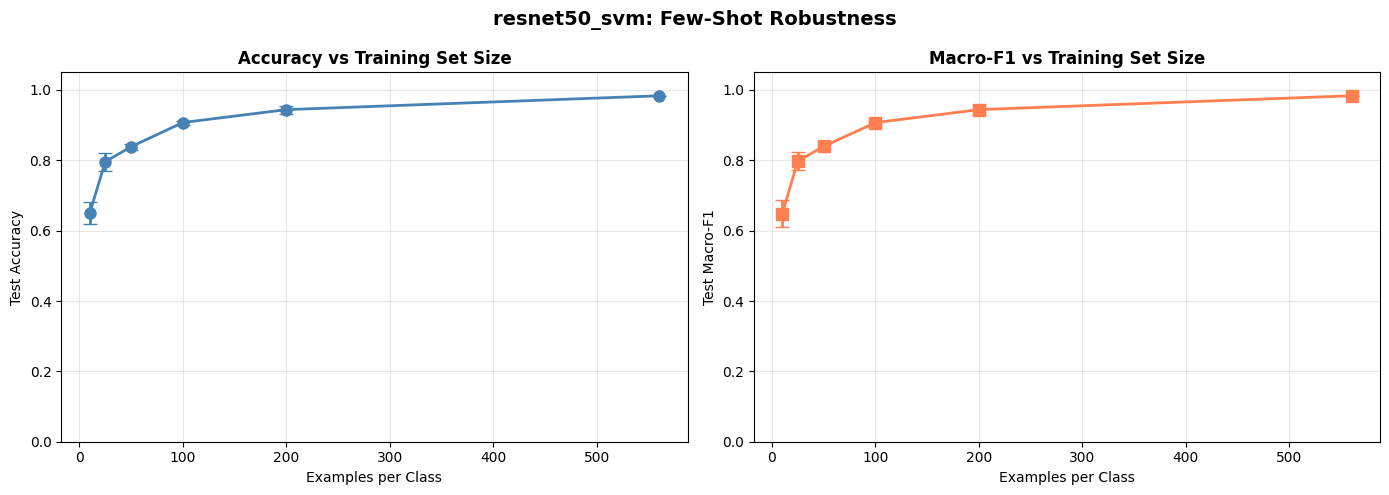

 n_per_class  acc_mean  acc_std  f1_mean   f1_std
          10  0.650000 0.030696 0.647690 0.038576
          25  0.796000 0.026111 0.797563 0.025052
          50  0.838667 0.008589 0.839548 0.007898
         100  0.907333 0.005735 0.906963 0.005570
         200  0.944000 0.011624 0.944041 0.011694
         560  0.983333 0.000000 0.983423 0.000000

 Output saved:
  - Graphs saved in: /content/drive/MyDrive/University/rare-neuro-mri/resnet utils
  - Artifacts and Weights saved in: /content/drive/MyDrive/University/rare-neuro-mri/restnet models


In [28]:
# ---------------------------------------------------------
# Metrics evaluations
# ---------------------------------------------------------

# Artifacts to pack
artifacts = {
    'svm': final_svm,
    'scaler': scaler_final,
    'class_names': disease_classes,
    'class_to_idx': train_ds.class_to_idx,
    'best_C': best_C
}

# Full execution of evaluation, plotting, few-shot, and saving
evaluate_and_save_all(
    y_true=y_test,
    y_pred=test_preds,
    class_names=disease_classes,
    utils_dir=UTILS_DIR,
    model_dir=MODEL_DIR,
    model_name="resnet50_svm",
    X_train_feats=x_train,
    y_train_labels=y_train,
    X_test_feats=x_test,
    artifacts_to_save=artifacts,
    torch_model_to_save=extractor,  # save backbone ResNet-50
    seed=SEED
)

> ### *Confusion Matrix (resnet50_svm)*
>
> *rows* = true label, \
*columns* = predicted label, \
*cell* = image count (60 per class on the diagonal at best)
>
> - **Perfect classes:** \
> `fukuyama_muscular_dystrophy` (60/60), `moyamoya_disease` (60/60) and `pachygyria_cerebellar_hypoplasia` (60/60). The last two are perfect in both directions: no false negatives *and* no false positives
> - **All 5 errors in detail:** \
> `hallervorden_spatz_disease` → **4** slices predicted as *fukuyama*; `walker_warburg_syndrome` → **1** slice predicted as *fukuyama*. Every single error in the whole test set lands in the same column
> - **Interpretation:** \
> the errors are **not scattered, they are systematic**. The decision region of *fukuyama* is slightly too generous, so it absorbs borderline cases from the other classes; that is exactly what its precision of 0.9231 (60 correct out of 65 predicted) measures \
> The dominant confusion `hallervorden_spatz → fukuyama` is worth an error analysis: inspecting those 4 slices (their plane, contrast, and whether they come from the same patient) would show whether the model is confusing pathology or simply acquisition style
>
 ---

> ### *Per-Class Metrics (resnet50_svm)*
>
> Precision / recall / F1 grouped by class — the bar-chart view of the classification report
>
> - Every bar sits **between 0.92 and 1.00**: \
> no class is being sacrificed for the average, which is the failure mode a single accuracy number would hide
> - The chart makes the **precision/recall trade-off visually obvious**: only two classes have unequal bars, and they are mirror images of each other — *fukuyama* (precision 0.92 < recall 1.00, it **over-attracts** predictions) and *hallervorden_spatz* (precision 1.00 > recall 0.93, it **loses** cases). *Moyamoya* and *pachygyria* show three identical bars at 1.00, *walker–warburg* only drops 0.02 in recall
> - F1 always sits between the two, so the lowest F1 (0.96, *fukuyama*) belongs to the class with the **highest** recall: a reminder that ranking classes by a single metric can be misleading
> - Because the test set is perfectly balanced, macro and weighted averages coincide (0.9834)

---

> ### *Few-Shot Robustness* (accuracy and macro-F1 vs. training-set size)
>
> The SVM is retrained on progressively larger subsets (10, 25, 50, 100, 200, 560 examples per class — 560 being the full augmented training set), repeated over several random draws; the error bars are the standard deviation across those repetitions
>
> | examples/class | accuracy | std | macro-F1 |
> |---|---|---|---|
> | 10 | 0.650 | 0.031 | 0.648 |
> | 25 | 0.796 | 0.026 | 0.798 |
> | 50 | 0.839 | 0.009 | 0.840 |
> | 100 | 0.907 | 0.006 | 0.907 |
> | 200 | 0.944 | 0.012 | 0.944 |
> | 560 | 0.983 | 0.000 | 0.983 |
>
> - The curve is a **classic logarithmic learning curve**: very steep up to ~100 examples per class, then clearly flattening
> - **With only 10 images per class the model already reaches 65% accuracy** against a 20% random baseline — the strongest argument for the frozen-backbone approach on rare diseases, where data is scarce by definition. Notice that the biggest single jump is 10 → 25 (+14.6 points): the first handful of examples per class is worth far more than the last few hundred
> - Going from 200 to 560 examples buys +3.9 accuracy points, so the curve is **approaching saturation**: more data of the same kind would yield diminishing returns, and further gains would more likely come from fine-tuning the backbone or from more diverse data
> - The **error bars shrink as the subsets grow** (std 0.031 at 10/class down to 0.006 at 100/class): with few images the result depends heavily on *which* ones are drawn. The bump back up at 200/class (0.012) shows the trend is noisy, not monotonic — the number of repetitions is small, so these std values are themselves rough estimates. At 560/class the std is exactly 0 because there is only one possible subset (the full set), so the experiment reduces to a single deterministic fit — which indeed returns the same 0.9833 as the main evaluation, a useful internal consistency check
> - Accuracy and macro-F1 overlap almost exactly at every size, confirming that no class collapses even in the low-data regime